<a href="https://colab.research.google.com/github/gabrielhierro/LinguagensDeProgramacao/blob/main/ExercicioPratico1.2/Exercicio_Pratico_1_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Análise de Vendas e Faturamento

## Configuração Inicial e Carregamento de Dados

In [16]:
import pandas as pd

# Preparação dos dados
# O arquivo dados.csv tem um caractere BOM e usa vírgula como separador decimal na coluna 'Preço'.
df = pd.read_csv('dados.csv', sep=',', encoding='utf-8-sig')

# Convert 'DataPedido' to datetime
df['DataPedido'] = pd.to_datetime(df['DataPedido'])

# Convert 'Preço' to numeric, handling comma as decimal separator
df['Preço'] = df['Preço'].str.replace(',', '.', regex=False)
df['Preço'] = pd.to_numeric(df['Preço'], errors='coerce') # 'coerce' will turn unparseable values into NaN

# Remove rows where 'Preço' became NaN after conversion
df.dropna(subset=['Preço'], inplace=True)

# Crie a coluna 'Faturamento_Total' que será usada em várias análises
df['Faturamento_Total'] = df['Unidades'] * df['Preço']

## Análise de Faturamento Total por Produto

Faturamento total por produto:


,Item,Faturamento_Total
0,Caixa de Som,9000.00
1,Fogão,653237.03
2,Geladeira,686538.50
3,Lavadora,199750.00
4,Mesa de Jantar,149424.90
5,Microondas,812850.00
6,Rack,4055.40
7,Sofá,178800.00
8,Televisão,108328.50


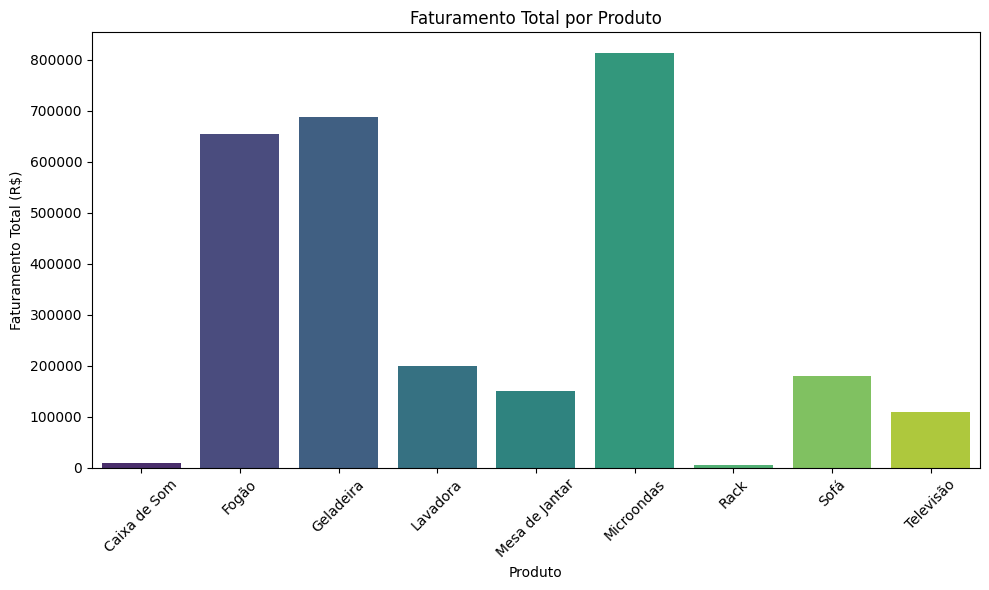

In [17]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agrupe por produto e calcule a soma do faturamento
faturamento_por_produto = df.groupby('Item')['Faturamento_Total'].sum().reset_index()

print("Faturamento total por produto:")
display(faturamento_por_produto)

# Gere o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Faturamento_Total', hue='Item', data=faturamento_por_produto, palette='viridis', legend=False)
plt.title('Faturamento Total por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análise de Faturamento Mensal

Faturamento mensal:


,Mes,Faturamento_Total
0,2020-01-01,2600.00
1,2020-02-01,166184.65
2,2020-03-01,45250.00
3,2020-04-01,7556.93
4,2020-06-01,39650.00
5,2020-07-01,95550.00
6,2020-08-01,52650.00
7,2020-11-01,42965.34
8,2021-01-01,50408.40
9,2021-02-01,120910.20


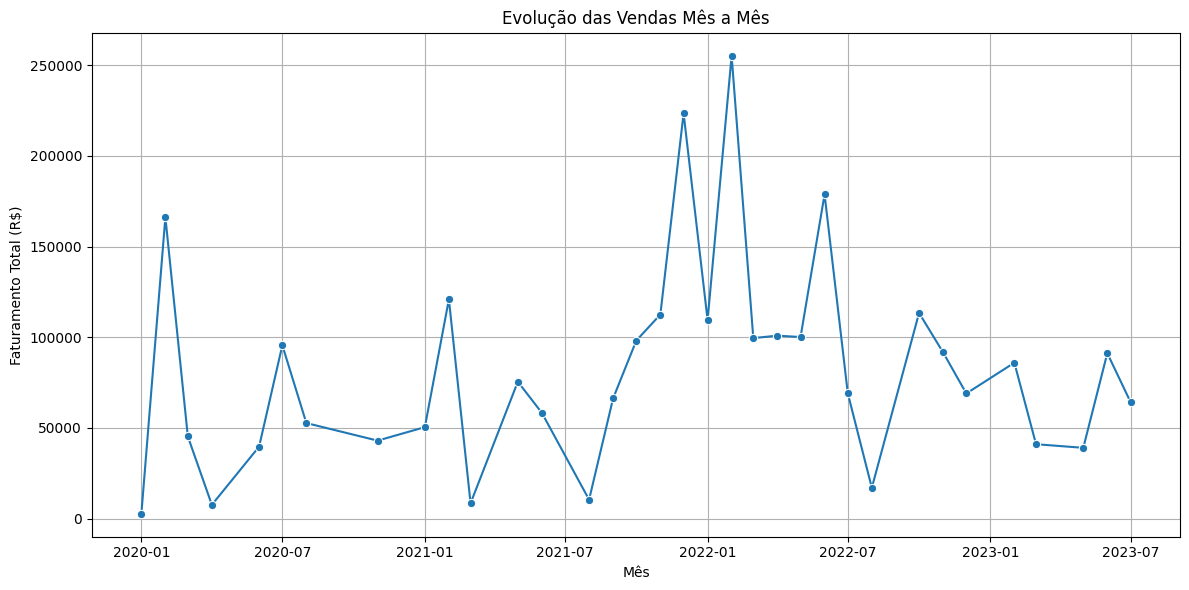

In [18]:
# Crie a coluna 'Mes'
df['Mes'] = df['DataPedido'].dt.to_period('M')

# Agrupe por mês e calcule o faturamento total
faturamento_mensal = df.groupby('Mes')['Faturamento_Total'].sum().reset_index()

# Converta a coluna 'Mes' de volta para datetime para facilitar a plotagem
faturamento_mensal['Mes'] = faturamento_mensal['Mes'].dt.to_timestamp()

print("Faturamento mensal:")
display(faturamento_mensal)

# Gere o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(x='Mes', y='Faturamento_Total', data=faturamento_mensal, marker='o')
plt.title('Evolução das Vendas Mês a Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Proporção de Itens Vendidos por Produto

Quantidade total vendida por produto:


,Item,Unidades
0,Caixa de Som,10
1,Fogão,1039
2,Geladeira,332
3,Lavadora,159
4,Mesa de Jantar,166
5,Microondas,1292
6,Rack,9
7,Sofá,149
8,Televisão,57


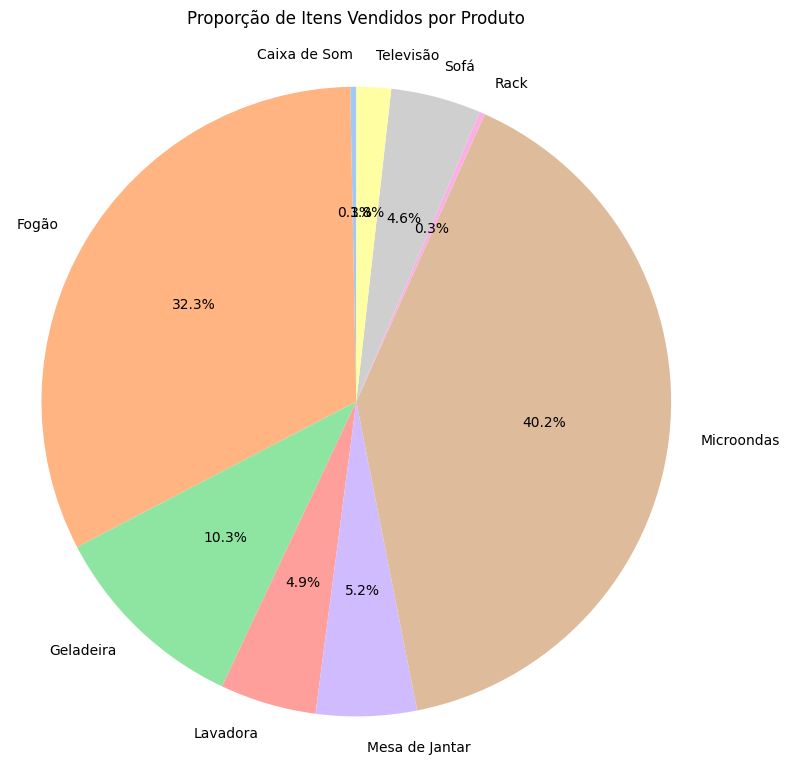

In [19]:
# Calcule a soma da quantidade vendida por produto
quantidade_por_produto = df.groupby('Item')['Unidades'].sum().reset_index()

print("Quantidade total vendida por produto:")
display(quantidade_por_produto)

# Gere o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(quantidade_por_produto['Unidades'], labels=quantidade_por_produto['Item'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proporção de Itens Vendidos por Produto')
plt.axis('equal') # Garante que o gráfico de pizza seja circular
plt.tight_layout()
plt.show()

## Aplicação Streamlit

O código da aplicação Streamlit foi salvo no arquivo `app_graficos.py` e pode ser executado a partir do terminal do Colab usando `!streamlit run app_graficos.py`. Abaixo está o conteúdo do arquivo.

## Análise de Faturamento por Produto

Faturamento total por produto:


,Item,Faturamento_Total
0,Caixa de Som,9000.00
1,Fogão,653237.03
2,Geladeira,686538.50
3,Lavadora,199750.00
4,Mesa de Jantar,149424.90
5,Microondas,812850.00
6,Rack,4055.40
7,Sofá,178800.00
8,Televisão,108328.50


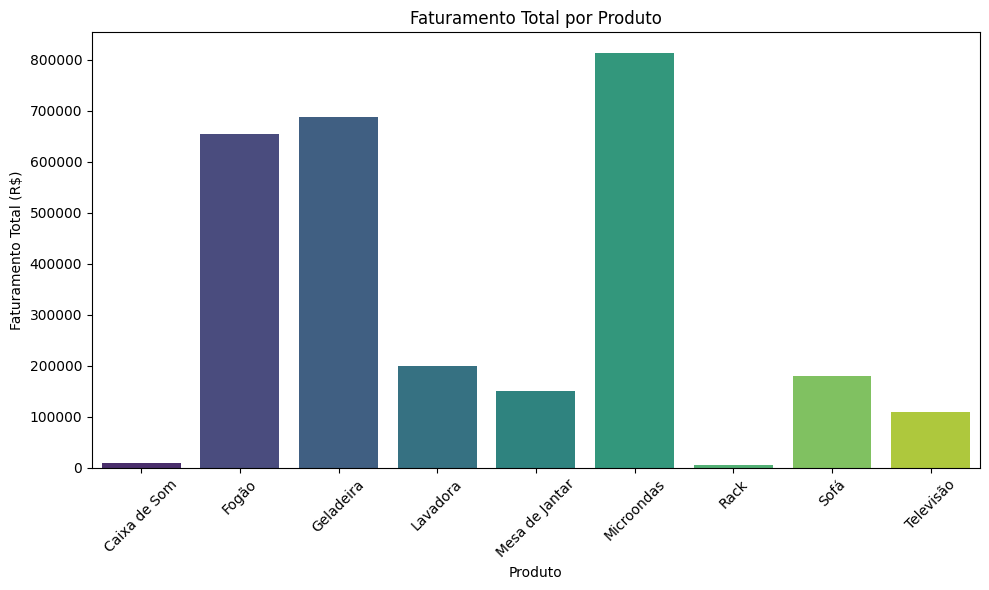

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Crie a coluna 'Faturamento_Total'
df['Faturamento_Total'] = df['Unidades'] * df['Preço']

# Agrupe por produto e calcule a soma do faturamento
faturamento_por_produto = df.groupby('Item')['Faturamento_Total'].sum().reset_index()

print("Faturamento total por produto:")
display(faturamento_por_produto)

# Gere o gráfico de barras
plt.figure(figsize=(10, 6))
sns.barplot(x='Item', y='Faturamento_Total', hue='Item', data=faturamento_por_produto, palette='viridis', legend=False)
plt.title('Faturamento Total por Produto')
plt.xlabel('Produto')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Análise de Faturamento Mensal

Faturamento mensal:


,Mes,Faturamento_Total
0,2020-01-01,2600.00
1,2020-02-01,166184.65
2,2020-03-01,45250.00
3,2020-04-01,7556.93
4,2020-06-01,39650.00
5,2020-07-01,95550.00
6,2020-08-01,52650.00
7,2020-11-01,42965.34
8,2021-01-01,50408.40
9,2021-02-01,120910.20


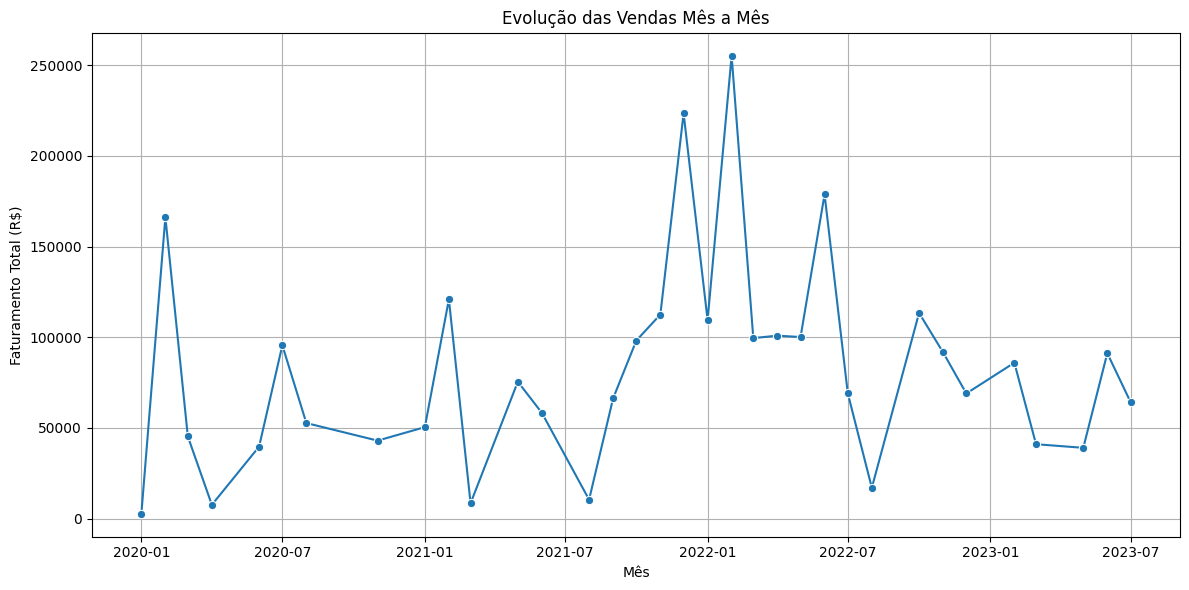

In [14]:
# Crie a coluna 'Mes'
df['Mes'] = df['DataPedido'].dt.to_period('M')

# Agrupe por mês e calcule o faturamento total
faturamento_mensal = df.groupby('Mes')['Faturamento_Total'].sum().reset_index()

# Converta a coluna 'Mes' de volta para datetime para facilitar a plotagem
faturamento_mensal['Mes'] = faturamento_mensal['Mes'].dt.to_timestamp()

print("Faturamento mensal:")
display(faturamento_mensal)

# Gere o gráfico de linha
plt.figure(figsize=(12, 6))
sns.lineplot(x='Mes', y='Faturamento_Total', data=faturamento_mensal, marker='o')
plt.title('Evolução das Vendas Mês a Mês')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.grid(True)
plt.tight_layout()
plt.show()

## Proporção de Itens Vendidos por Produto

Quantidade total vendida por produto:


,Item,Unidades
0,Caixa de Som,10
1,Fogão,1039
2,Geladeira,332
3,Lavadora,159
4,Mesa de Jantar,166
5,Microondas,1292
6,Rack,9
7,Sofá,149
8,Televisão,57


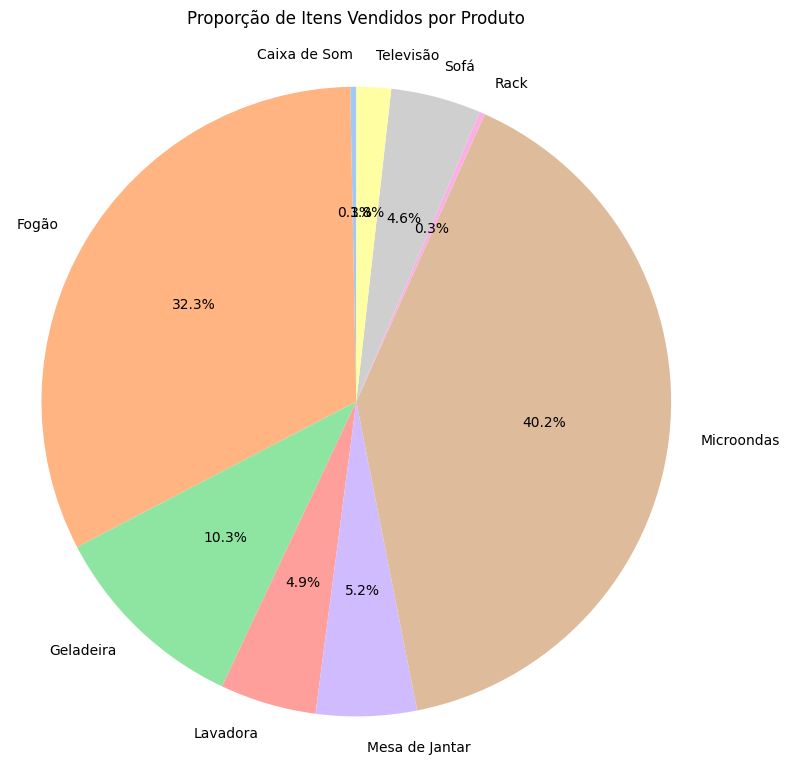

In [15]:
# Calcule a soma da quantidade vendida por produto
quantidade_por_produto = df.groupby('Item')['Unidades'].sum().reset_index()

print("Quantidade total vendida por produto:")
display(quantidade_por_produto)

# Gere o gráfico de pizza
plt.figure(figsize=(8, 8))
plt.pie(quantidade_por_produto['Unidades'], labels=quantidade_por_produto['Item'], autopct='%1.1f%%', startangle=90, colors=sns.color_palette('pastel'))
plt.title('Proporção de Itens Vendidos por Produto')
plt.axis('equal') # Garante que o gráfico de pizza seja circular
plt.tight_layout()
plt.show()

## Média de Faturamento Mensal

In [21]:
media_faturamento_mensal = faturamento_mensal['Faturamento_Total'].mean()

print(f"A média de faturamento mensal é de R$ {media_faturamento_mensal:.2f}")

A média de faturamento mensal é de R$ 82411.30


### Visualização da Média de Faturamento Mensal

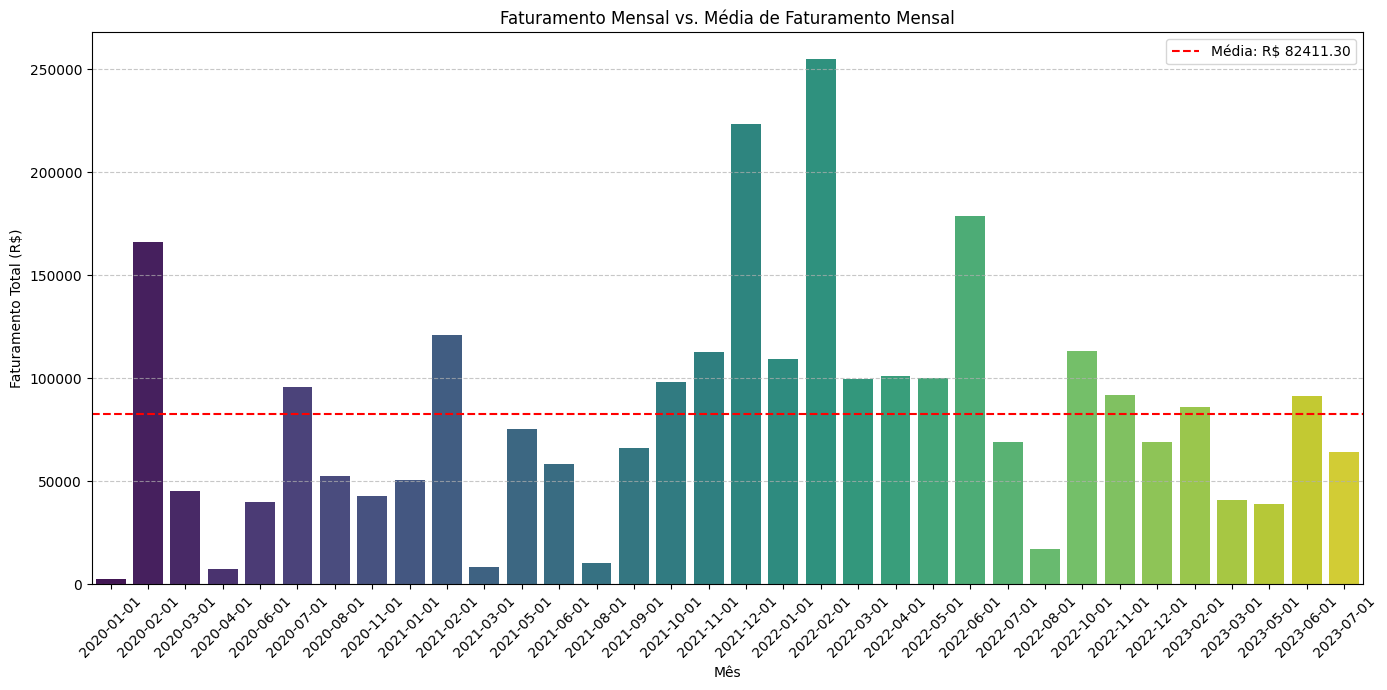

In [23]:
plt.figure(figsize=(14, 7))
sns.barplot(x='Mes', y='Faturamento_Total', hue='Mes', data=faturamento_mensal, palette='viridis', legend=False)
plt.axhline(media_faturamento_mensal, color='red', linestyle='--', label=f'Média: R$ {media_faturamento_mensal:.2f}')
plt.title('Faturamento Mensal vs. Média de Faturamento Mensal')
plt.xlabel('Mês')
plt.ylabel('Faturamento Total (R$)')
plt.xticks(rotation=45)
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()